# Week 11 — Train empirical-distribution diffusion (11c)

This notebook trains a reverse-diffusion model whose target is the **empirical**
per-window latitude distribution — not the residual against the parametric
classical. The classical density acts as a *prior* via a KL regularizer
instead of a fixed pedestal. Two physical constraints (non-negativity and
integration to 1) are enforced by construction: training happens in a
standardized logit space, and sampling decodes via softmax.

## Why a separate notebook

Week-11 ablations on the residual target showed no variant beating the
classical baseline on normalized NLL, and the oracle gap pointed at the
target framing rather than at architecture: cond carries almost no
predictive information about the residual because the classical already
exploits the same inputs. Switching the target to the empirical distribution
lets cond re-explain bulk *and* fine structure jointly.

## Pipeline

1. Re-use the v2 parquet built by `11_train_and_evaluate.ipynb` (no rebuild).
2. Build `EmpiricalDistributionDataset` (Laplace-smoothed mass → mean-centered
   logits → per-bin standardization), plus a per-window classical Dirichlet
   prior for the KL term.
3. Define `EXPERIMENTS_EMP` — same `_spec` template as the residual notebook,
   starting with E0 = base cond + concat arch, with space for E1+ to add
   cond_opp / cond_traj / FiLM / Fourier / CFG.
4. Train each variant with `train_empirical_experiment`. Checkpoints are
   saved as `ckpt_emp_<name>.ckpt` so they coexist with the residual
   `ckpt_<name>.ckpt` files.
5. Per-variant diagnostic: decoded sample density vs the classical density at
   one val window. Confirms the model is producing valid simplex outputs that
   are neither pinned to classical (KL too strong) nor random (KL too weak).

Evaluation lives in `11d_evaluate_empirical.ipynb`.

In [1]:
# Standard Week 10/11 setup: locate the repo, install if missing.
import os, subprocess, sys

# Use this path if working locally; switch to /content/butterflai in Colab.
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

There is no tracking information for the current branch.
Please specify which branch you want to merge with.
See git-pull(1) for details.

    git pull <remote> <branch>

If you wish to set tracking information for this branch you can do so with:

    git branch --set-upstream-to=origin/<branch> feature/week11



git pull skipped: Command '['git', '-C', '../../', 'pull']' returned non-zero exit status 1.
  Installing from /d0/amunozj/git_repos/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn.functional as F

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb

In [3]:
# Bootstrap sys.path — same pattern as 11b. The week_10 conditioned_infrastructure
# is loaded first to use its find_week10_artifacts, then we repoint to week_11
# so subsequent imports of conditioned_infrastructure / empirical_infrastructure
# pick up the week_11 versions.
_week09_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_09"))
_week10_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_10"))
_week11_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_11"))
for _p in (_week09_dir, _week11_dir, _week10_dir):
    if _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("conditioned_infrastructure", None)

from conditioned_infrastructure import find_week10_artifacts
paths = find_week10_artifacts(extra_required=[
    "data/composite_sunspot_groups_peak_area.csv",
])
if _week11_dir in sys.path:
    sys.path.remove(_week11_dir)
sys.path.insert(0, _week11_dir)
sys.modules.pop("conditioned_infrastructure", None)
sys.modules.pop("empirical_infrastructure", None)

from unconditioned_infrastructure import make_cosine_schedule
from butterflAI_model import ButterflAIModel
from empirical_infrastructure import (
    EmpiricalDistributionDataset,
    ExtendedConditionalEmpiricalDiffusionLightning,
    sample_empirical_extended,
    train_empirical_experiment,
    load_trained_empirical_experiment,
    discover_emp_experiment_checkpoints,
    classical_mass_at_bins,
    EMP_CKPT_PREFIX,
)

_WEEK10_DIR = paths["week10_dir"]
PARQUET_V2  = os.path.join(_WEEK10_DIR, "diffusion_windows_v2.parquet")
CKPT_DIR    = _WEEK10_DIR

classical   = ButterflAIModel(paths["classical_weights"])

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PARQUET_V2: {PARQUET_V2}")
print(f"CKPT_DIR  : {CKPT_DIR}")
print(f"device    : {device}")

PARQUET_V2: /d0/amunozj/git_repos/butterflai/weeks/week_10/diffusion_windows_v2.parquet
CKPT_DIR  : /d0/amunozj/git_repos/butterflai/weeks/week_10
device    : cuda


In [4]:
# Load the v2 parquet — already built by 11_train_and_evaluate.ipynb. Do NOT
# rebuild here. Test split is reserved for the PI; this notebook works on
# train+val only.
windows_v2 = pd.read_parquet(PARQUET_V2)
windows_v2 = windows_v2.loc[windows_v2["split"].isin(["train", "val"])].reset_index(drop=True)
windows_aug = windows_v2  # API parity with train_experiment
print(f"v2 parquet rows (train+val): {len(windows_v2)}")
print(f"  splits: {windows_v2['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles: {sorted(windows_v2['cycle'].unique())}")

v2 parquet rows (train+val): 287
  splits: {'train': 232, 'val': 55}
  cycles: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


## Experiment registry

`EXPERIMENTS_EMP` mirrors the residual `EXPERIMENTS` dict so adding cond groups,
switching to FiLM / Fourier, or enabling classifier-free guidance is a single
dict edit. Two new keys specific to the empirical target:

- `lambda_kl` — weight on `KL(p_model || p_classical)`. Default 0.1. Set to 0
  to remove the classical anchor entirely; raise toward 1–3 if generated
  distributions drift unphysically far from classical.
- `alpha_smooth`, `n_pseudo_obs` — Laplace smoothing strength on the
  empirical histogram target. Defaults `alpha=1`, `n_pseudo=30` give a mild
  ~1/3 convex blend against the uniform prior, enough to dampen single-bin
  spikes in low-count windows without flattening real bimodality.

We start with **E0 = base cond, concat arch** only; the commented templates
below show how to add cond_opp / cond_traj / FiLM / Fourier / CFG variants.
Keep variant names disjoint from the residual notebook's `EXPERIMENTS` so the
checkpoint files (`ckpt_emp_*.ckpt`) never collide with `ckpt_*.ckpt`.

In [5]:
_BASE_TEMPLATE = {
    "arch":           "concat",
    "consumed_keys":  ["cond_base"],
    "groups":         ["base"],
    "hidden_dim":     128,
    "n_layers":       3,
    "fourier":        False,
    "cond_dropout_p": 0.0,
    "max_epochs":     5000,
    "lr":             1e-3,
    "batch_size":     64,
    # Empirical-target specific knobs.
    "lambda_kl":      0.1,
    "alpha_smooth":   1.0,
    "n_pseudo_obs":   30.0,
}

def _spec(**overrides):
    d = dict(_BASE_TEMPLATE); d.update(overrides); return d

EXPERIMENTS_EMP = {
    # Baseline — base cond, concat arch, KL anchor to classical.
    "E0": _spec(),

    # Uncomment to add variants. Same patterns as the residual EXPERIMENTS dict.
    "E1": _spec(consumed_keys=["cond_base", "cond_cyclehemi"],
                groups=["base", "cyclehemi"]),
    "E2": _spec(consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"]),
    "E3": _spec(consumed_keys=["cond_base", "cond_traj"],
                groups=["base", "traj"]),
    "E4": _spec(arch="film"),
    "E5": _spec(arch="film",
                consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"]),
    "E6_cfg": _spec(arch="film",
                    consumed_keys=["cond_base", "cond_opp"],
                    groups=["base", "opp"],
                    cond_dropout_p=0.1),
    "E7_fourier": _spec(arch="film", fourier=True,
                        consumed_keys=["cond_base", "cond_opp"],
                        groups=["base", "opp"]),
}

for name, cfg in EXPERIMENTS_EMP.items():
    print(f"{name}: arch={cfg['arch']:6s}  consumed={cfg['consumed_keys']}  "
          f"lambda_kl={cfg['lambda_kl']}  alpha_smooth={cfg['alpha_smooth']}")

E0: arch=concat  consumed=['cond_base']  lambda_kl=0.1  alpha_smooth=1.0
E1: arch=concat  consumed=['cond_base', 'cond_cyclehemi']  lambda_kl=0.1  alpha_smooth=1.0
E2: arch=concat  consumed=['cond_base', 'cond_opp']  lambda_kl=0.1  alpha_smooth=1.0
E3: arch=concat  consumed=['cond_base', 'cond_traj']  lambda_kl=0.1  alpha_smooth=1.0
E4: arch=film    consumed=['cond_base']  lambda_kl=0.1  alpha_smooth=1.0
E5: arch=film    consumed=['cond_base', 'cond_opp']  lambda_kl=0.1  alpha_smooth=1.0
E6_cfg: arch=film    consumed=['cond_base', 'cond_opp']  lambda_kl=0.1  alpha_smooth=1.0
E7_fourier: arch=film    consumed=['cond_base', 'cond_opp']  lambda_kl=0.1  alpha_smooth=1.0


## wandb setup

Same per-student project convention as `11_train_and_evaluate.ipynb`. The
empirical runs go to a sibling project (suffix `-emp`) so the residual and
empirical dashboards stay separable; switch to the same project as the
residual notebook if you want them side-by-side.

If wandb is unavailable, `train_empirical_experiment` falls back to a local
`CSVLogger` under `CKPT_DIR/csv_logs/`.

In [6]:
WANDB_PROJECT = "butterflai-w10ext-amunoz-emp"
WANDB_ENTITY  = None

## Training

`train_empirical_experiment` is idempotent: if `ckpt_emp_<name>.ckpt` already
exists in `CKPT_DIR`, it skips training. Delete the file (or change the
experiment name) to force a retrain.

Training uses the same DDIM cosine schedule and AdamW optimizer as the
residual notebook; the only loss-side difference is the additive
`KL(p_model || p_classical)` term computed by recovering the predicted clean
logits, softmaxing, and comparing against the per-window classical mass
carried in the batch (`m_classical`).

In [7]:
for name, cfg in EXPERIMENTS_EMP.items():
    print(f"\n=== training {name} ===")
    train_empirical_experiment(
        name=name, cfg=cfg, windows_aug=windows_aug,
        classical=classical, bin_centers=BIN_CENTERS,
        ckpt_dir=CKPT_DIR, alpha_np=alpha_np, sigma_np=sigma_np, T=T,
        bin_width=BIN_WIDTH,
        wandb_project=WANDB_PROJECT, wandb_entity=WANDB_ENTITY,
    )

trained = discover_emp_experiment_checkpoints(CKPT_DIR)
print(f"\ntrained empirical checkpoints: {list(trained)}")

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision 


=== training E0 ===


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: Currently logged in as: andres-munoz (butterflai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loading `train_dataloader` to estimate number of stepping batches.
/d0/amunozj/.conda/envs/surya_ws/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/d0/amunozj/.conda/envs/surya_ws/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type                                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model        │ ExtendedConcatConditionalDiffusionMLP │ 78.7 K │ train │     0 │
│   │ other params │ n/a                                   │      4 │ n/a   │   n/a │
└───┴──────────────┴───────────────────────────────────────┴────────┴───────┴───────┘

...

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type                        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model        │ FiLMConditionalDiffusionMLP │  148 K │ train │     0 │
│   │ other params │ n/a                         │      7 │ n/a   │   n/a │
└───┴──────────────┴─────────────────────────────┴────────┴───────┴───────┘

Trainable params: 148 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 148 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/d0/amunozj/.conda/envs/surya_ws/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=5000` reached.
`weights_only` was not set, defaulting to `False`.


epoch,▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇███
kl_loss,▇▅▅▆▅▄▆▄▁▄▅▃▃▂▃▅▅▅▅▃▂▃▅▄█▂▅▃▃▄▅▃▆▄▄▂▄▄▄▄
mse_loss,▁▁▁▂▁▁▃▃▃▃▃▁▄▁▁▃▁▁▁▄▇▁▁▁▄▆▁▁█▁▅▇▁▁▁▁███▁
train_loss,█▅▄▄▄▃▃▃▂▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▂▂▁▁▁▁▁▁▁▁▂▁▁
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇█
val_loss,▁▁▁▁▁▂▂▂▂▂▃▂▂▂▂▂▂▂▃▃▄▃▄▃▄▃▄▃▃▄█▄▃▃▄▃▆▂▃▄
epoch,4999
kl_loss,0.63193
mse_loss,0.04743
train_loss,0.11062
trainer/global_step,19999


[E7_fourier] saved /d0/amunozj/git_repos/butterflai/weeks/week_10/ckpt_emp_E7_fourier.ckpt

trained empirical checkpoints: ['E0', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6_cfg', 'E7_fourier']


## Quick-look diagnostic

For each trained variant, sample K=20 densities on one val window and plot
their mean against the classical density at that window. Three failure
modes to look for:

- Sample mean **pinned to classical** → `lambda_kl` is too strong; lower it.
- Sample mean **near uniform** → KL too strong or training under-converged.
- Sample mean **wildly different from classical with high variance across K** →
  KL too weak / training noise dominates. Raise `lambda_kl` or `max_epochs`.

The simplex check at the top of the cell is the architectural guarantee:
every sample is non-negative and integrates to 1 to float32 precision.

E0: non-negative=True  |Σp·Δℓ - 1|_max=1.19e-07
E1: non-negative=True  |Σp·Δℓ - 1|_max=1.19e-07
E2: non-negative=True  |Σp·Δℓ - 1|_max=1.19e-07
E3: non-negative=True  |Σp·Δℓ - 1|_max=1.19e-07
E4: non-negative=True  |Σp·Δℓ - 1|_max=1.19e-07
E5: non-negative=True  |Σp·Δℓ - 1|_max=2.38e-07
E6_cfg: non-negative=True  |Σp·Δℓ - 1|_max=1.19e-07
E7_fourier: non-negative=True  |Σp·Δℓ - 1|_max=1.19e-07


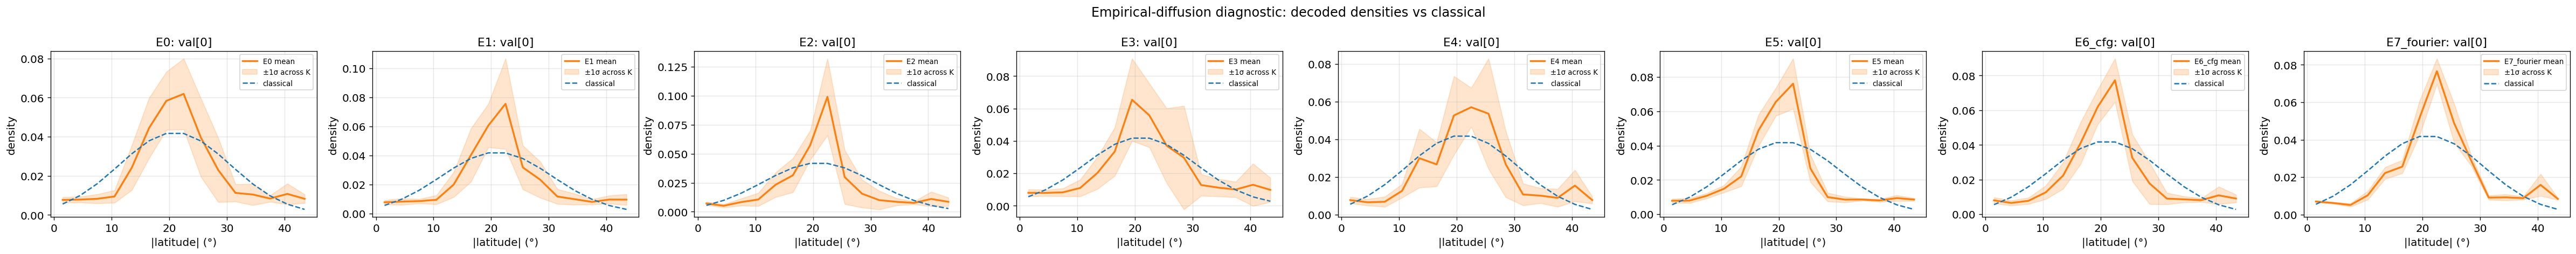

In [8]:
import scipy.stats as _sst

if not trained:
    print("no trained checkpoints found — run the training cell above first")
else:
    n_show = len(trained)
    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4), squeeze=False)
    axes = axes[0]

    for ax, (name, _) in zip(axes, trained.items()):
        cfg = EXPERIMENTS_EMP[name]
        lit, train_ds, val_ds, total_dim = load_trained_empirical_experiment(
            name=name, cfg=cfg, windows_aug=windows_aug,
            classical=classical, bin_centers=BIN_CENTERS,
            ckpt_dir=CKPT_DIR, alpha_np=alpha_np, sigma_np=sigma_np,
            bin_width=BIN_WIDTH,
        )

        idx = 0
        cond_one = torch.cat(
            [val_ds[idx][k] for k in cfg["consumed_keys"]], dim=-1
        ).unsqueeze(0).repeat(20, 1)
        torch.manual_seed(0)
        p_samples = sample_empirical_extended(
            lit, cond_one, guidance_w=0.0, bin_width=BIN_WIDTH, device=device,
        ).cpu().numpy()

        nonneg = (p_samples >= 0).all()
        mass   = (p_samples * BIN_WIDTH).sum(axis=-1)
        print(f"{name}: non-negative={nonneg}  |Σp·Δℓ - 1|_max={np.abs(mass - 1).max():.2e}")

        m_cl = val_ds._m_classical[idx].numpy() / BIN_WIDTH  # mass -> density

        ax.plot(BIN_CENTERS, p_samples.mean(axis=0), "C1-", lw=2, label=f"{name} mean")
        ax.fill_between(
            BIN_CENTERS,
            p_samples.mean(axis=0) - p_samples.std(axis=0),
            p_samples.mean(axis=0) + p_samples.std(axis=0),
            color="C1", alpha=0.2, label="±1σ across K",
        )
        ax.plot(BIN_CENTERS, m_cl, "C0--", lw=1.5, label="classical")
        ax.set_xlabel("|latitude| (°)")
        ax.set_ylabel("density")
        ax.set_title(f"{name}: val[{idx}]")
        ax.legend(fontsize=8)

    fig.suptitle("Empirical-diffusion diagnostic: decoded densities vs classical")
    fig.tight_layout()
    plt.show()